В цьому домашньому завданні ми з вами побудуємо повноцінне ML-рішення реальної ML-задачі. Ви вже маєте всі знання, які для цього потрібні. Дотримуйтесь інструкцій, та користуйтесь матеріалами лекцій, аби виконувати завдання. Тут інструкції будуть детальні, а в подільших завданнях - будуть ставати все менш детальними, аби ви вже починали самостійно структурувати ML-проєкт і до кінця курсу для вас розвʼязати будь-яку ML–задачу було eazy-breezy.

## Dataset

Будемо працювати з набором даних `cars.csv`, який описує автомобілі і їх ціну у індійських рупіях :) Мета - передбачити ціну авто за його характеристиками. Опис набору даних:

| Назва рядка            | Опис                                                                                                                                                 |
|------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------|
| Car_ID                 | Унікальний ідентифікатор для кожного оголошення про автомобіль.                                                                                         |
| Brand                  | Бренд або виробник автомобіля (наприклад, Toyota, Honda, Ford тощо).                                                                                     |
| Model                  | Модель автомобіля (наприклад, Camry, Civic, Mustang тощо).                                                                                               |
| Year                   | Рік виготовлення автомобіля.                                                                                                                            |
| Kilometers_Driven      | Загальний пробіг автомобіля у кілометрах.                                                                                                               |
| Fuel_Type              | Тип палива, який використовує автомобіль (наприклад, бензин, дизель, електро тощо).                                                                      |
| Transmission           | Тип трансмісії автомобіля (наприклад, механічна, автоматична).                                                                                           |
| Owner_Type             | Кількість попередніх власників автомобіля (наприклад, перший, другий, третій).                                                                           |
| Mileage                | Паливна ефективність автомобіля у кілометрах на літр.                                                                                                   |
| Engine                 | Об'єм двигуна автомобіля в кубічних сантиметрах (CC).                                                                                                   |
| Power                  | Максимальна потужність автомобіля в кінських силах (bhp).                                                                                               |
| Seats                  | Кількість місць в автомобілі.                                                                                                                           |
| Price                  | Вартість автомобіля в INR (індійські рупії), що є цільовою змінною для прогнозування.                                                                   |

# Імпорти

Для зручності рекомендую всі імпорти розмістити тут нагорі, аби коли ви перезавантажували ноутбук, одразу можна було в один запуск клітинки імпортувати всі потрібні бібліотеки.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.metrics import root_mean_squared_error
import statsmodels.api as sm

# Знайомство з даними

**Завдання 1.** Завантажте набір даних `cars.csv` в pandas.DataFrame. Виведіть перші 5 записів.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
cars_df = pd.read_csv('/content/drive/MyDrive/ML1/data/cars.csv')
cars_df.head()

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,1,Toyota,Corolla,2018,50000,Petrol,Manual,First,15,1498,108,5,800000
1,2,Honda,Civic,2019,40000,Petrol,Automatic,Second,17,1597,140,5,1000000
2,3,Ford,Mustang,2017,20000,Petrol,Automatic,First,10,4951,395,4,2500000
3,4,Maruti,Swift,2020,30000,Diesel,Manual,Third,23,1248,74,5,600000
4,5,Hyundai,Sonata,2016,60000,Diesel,Automatic,Second,18,1999,194,5,850000


**Завдання 2.** Виведіть типи даних колонок даних, а також дослідіть, які по факту типи даних мають записи в кожній колонці (тип `object` може містити різні типи даних) і скільки значень є в кожній категоріальній колонці.

Напишіть висновок, скільки в наборі даних числових та категоріальних колонок кожного з трьох різних типів (бінарна, мільтикатегоріальна без порядку, мультикатегоріальна з порядком). Шаблон висновку

```
В наборі даних 10 числових і 10 категоріальних колонок з них
- 2 бінарні (мають лише 2 значення)
- 6 мультикатегоріальних (більше 2х значень) зі значеннями, для яких немає відношення порядку
- 2 колонки, в яких можна встановити відношення порядку (наприклад Small<Medium<Large)
```

Якщо не знаєте, як це зробити з `pandas` - ось підказка, які методи можуть допомогти вам виконати це завдання

- pandas.DataFrame.info()
- pandas.DataFrame.dtypes
- pandas.DataFrame.loc[...]
- pandas.DataFrame.select_dtypes(...)
- pandas.Series.unique()
- pandas.Series.nunique()

Детальніше ознайомитись з кожним ви можете в [документації](https://pandas.pydata.org/docs/reference/frame.html), або написати в окремій клітинці знак питання і назву методу (тільки приберіть це перед здачею, бо перегляд документації - не допомагає зрозуміти дані і хід думок, а Ваша робота - це як презентація замовнику зробленої задачі).


In [6]:
# приклад як викликати документацію, якщо у Вас pandas імпортований як pd
?pd.DataFrame.info

In [5]:
# Типи даних
cars_df.dtypes

,0
Car_ID,int64
Brand,object
Model,object
Year,int64
Kilometers_Driven,int64
Fuel_Type,object
Transmission,object
Owner_Type,object
Mileage,int64
Engine,int64


In [11]:
# Детальна інформація
cars_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Car_ID             100 non-null    int64 
 1   Brand              100 non-null    object
 2   Model              100 non-null    object
 3   Year               100 non-null    int64 
 4   Kilometers_Driven  100 non-null    int64 
 5   Fuel_Type          100 non-null    object
 6   Transmission       100 non-null    object
 7   Owner_Type         100 non-null    object
 8   Mileage            100 non-null    int64 
 9   Engine             100 non-null    int64 
 10  Power              100 non-null    int64 
 11  Seats              100 non-null    int64 
 12  Price              100 non-null    int64 
dtypes: int64(8), object(5)
memory usage: 10.3+ KB


In [12]:
# Числові колонки
cars_df.select_dtypes(include='number')

,Car_ID,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Price
0,1,2018,50000,15,1498,108,5,800000
1,2,2019,40000,17,1597,140,5,1000000
2,3,2017,20000,10,4951,395,4,2500000
3,4,2020,30000,23,1248,74,5,600000
4,5,2016,60000,18,1999,194,5,850000
...,...,...,...,...,...,...,...,...
95,96,2019,22000,16,1950,191,5,2900000
96,97,2017,38000,13,2755,171,7,1400000
97,98,2018,26000,18,1497,121,5,750000
98,99,2019,24000,17,1497,113,5,850000


In [13]:
# Категоріальні колонки & кількість унікальних значень
cars_df.select_dtypes(include='object').nunique()

,0
Brand,11
Model,58
Fuel_Type,2
Transmission,2
Owner_Type,3


In [14]:
# Значення в кожній категоріальній колонці
for col in cars_df.select_dtypes(include='object').columns:
    print(f"\n{col} ({cars_df[col].nunique()} значень):")
    print(cars_df[col].unique())


Brand (11 значень):
['Toyota' 'Honda' 'Ford' 'Maruti' 'Hyundai' 'Tata' 'Mahindra' 'Volkswagen'
 'Audi' 'BMW' 'Mercedes']

Model (58 значень):
['Corolla' 'Civic' 'Mustang' 'Swift' 'Sonata' 'Nexon' 'Scorpio' 'Polo'
 'A4' 'X1' 'C-Class' 'Endeavour' 'Creta' 'Harrier' 'Ertiga' 'City'
 'Tiguan' 'Q3' '5 Series' 'GLC' 'Innova' 'Figo' 'Verna' 'Altroz' 'Thar'
 'Passat' 'A6' 'X3' 'E-Class' 'Fortuner' 'Aspire' 'Elantra' 'Safari'
 'Vitara' 'WR-V' 'Ameo' 'A3' '7 Series' 'GLE' 'Yaris' 'Ranger' 'Santro'
 'Tigor' 'S-Cross' 'BR-V' 'T-Roc' 'Q7' 'X5' 'GLA' 'Camry' 'Venue' 'Tiago'
 'XUV300' 'Vento' 'A5' '3 Series' 'Innova Crysta' 'EcoSport']

Fuel_Type (2 значень):
['Petrol' 'Diesel']

Transmission (2 значень):
['Manual' 'Automatic']

Owner_Type (3 значень):
['First' 'Second' 'Third']


**Висновок**

числових колонок **8** (Car_ID, Year, Kilometers_Driven, Mileage, Engine, Power, Seats, Price)
категоріальних - 5 (включаючи 2 бінарні Fuel_Type, Transmission);

2 колонки мультикатегоріальні (Brand, Model);

1 мультикатегоріальна з порядком (Owner_Type: First / Second / Third).

Усі колонки не мають налів. Car_ID - це просто айді у системі для моделі не має сенсу.


**Завдання 3**. Розділіть дані на тренувальні і тест. Відведіть в тест 20%, поставте `random_state=12`. Ми будемо передбачати колонку `Price` - тож, вона є цільовою змінною. В результаті у Вас має бути 4 набори даних `X_train, X_test, y_train, y_test`.

Надалі ми всюди тренуємо методи для кодування, масштабування та саму модель тільки на тренувальних даних X_train (та y_train для моделі), а на тестувальних лише використовуємо вже навчені методи для кодування, масштабування і модель викликаючи в них `transform()` (для методів обробки даних) або `predict()` (для моделі).

І так само треба робити завжди.

In [15]:
from sklearn.model_selection import train_test_split

#  Ми будемо передбачати колонку Price - тож, вона є цільовою змінною.
X = cars_df.drop(columns=['Price'])
y = cars_df['Price']

# Train/test split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=12
)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

X_train: (80, 12)
X_test:  (20, 12)
y_train: (80,)
y_test:  (20,)


**Завдання 4**. Кодуємо категоріальні колонки.

1. Закодуйте колонки з бінарними значеннями `Fuel_Type` і `Transmission` так, аби вони були у чисельному представленні і містили лише 0 так 1. Приклад був у лекції. Значення 1 нехай буде у категорії, яка містить більше значень в колонці.

2. Закодуйте колонку `Brand` з використанням `sklearn.preprocessing.OneHotEncoder` аналогічно до того, як ми робили це в лекції. Увага! Ми робимо виклик методу `Encoder.fit()` на тренувальних даних `X_train`, а на тестувальних тільки викликаємо `Encoder.transform()`. Додайте закодовані значення в набори даних `X_train`, `X_test`.

3. Колонку `Owner_Type` з використанням `sklearn.preprocessing.OrdinalEncoder` я закодую для вас. Проаналізуйте, що відбувається.

Колонка `Model` містять забагато значень для кодування в тому вигляді, як вона є зараз, з огляду на невелику кількість даних. Якщо ви бачите, як можна згрупувати значення в цій колонці скоротивши кількість унікальних значень до 3-5, то можете виконати ще цю трансформацію, використати цю колонку в моделі і отримати додаткову практику і бал, якщо все буде зроблено правильно. А якщо неправильно - то фідбек на Вашу роботу :)

In [17]:
cars_df['Fuel_Type'].value_counts()

,count
Fuel_Type,
Petrol,52
Diesel,48


In [19]:
cars_df['Transmission'].value_counts()

,count
Transmission,
Automatic,57
Manual,43


In [20]:
# 1 Fuel_Type/ Transmission

# Petrol=1 (більше значень), Diesel=0
fuel_codes = {'Petrol': 1, 'Diesel': 0}
X_train['Fuel_Type_Code'] = X_train['Fuel_Type'].map(fuel_codes)
X_test['Fuel_Type_Code'] = X_test['Fuel_Type'].map(fuel_codes)

# Automatic=1 (більше значень), Manual=0
transmission_codes = {'Automatic': 1, 'Manual': 0}
X_train['Transmission_Code'] = X_train['Transmission'].map(transmission_codes)
X_test['Transmission_Code'] = X_test['Transmission'].map(transmission_codes)

In [22]:
# Перевірка бінарного кодування
print(X_train[['Fuel_Type', 'Fuel_Type_Code', 'Transmission', 'Transmission_Code']].head())

   Fuel_Type  Fuel_Type_Code Transmission  Transmission_Code
83    Petrol               1    Automatic                  1
55    Diesel               0    Automatic                  1
26    Petrol               1    Automatic                  1
54    Petrol               1       Manual                  0
19    Petrol               1    Automatic                  1


In [24]:
# 2
enc = OneHotEncoder(sparse_output=False)
enc.fit(X_train[['Brand']])

brand_cols = enc.categories_[0]
X_train[brand_cols] = enc.transform(X_train[['Brand']])
X_test[brand_cols] = enc.transform(X_test[['Brand']])

In [25]:
# 3
from sklearn.preprocessing import OrdinalEncoder

ordenc = OrdinalEncoder(categories=[['First', 'Second', 'Third']]) # визначаємо порядок категорій
ordenc.fit(X_train[['Owner_Type']])

X_train['Owner_Type_Codes'] = ordenc.transform(X_train[['Owner_Type']])
X_test['Owner_Type_Codes'] = ordenc.transform(X_test[['Owner_Type']])

Очікуваний результат після трансформацій:

In [26]:
pd.set_option('display.max_columns', 100)
display(X_train.head()), display(X_test.head())

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Owner_Type_Codes,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,0,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,1,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Owner_Type_Codes,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen
17,18,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,148,5,1,1,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
41,42,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,68,5,1,0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
92,93,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
14,15,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,103,7,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
68,69,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,94,5,1,0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


(None, None)

**Висновок №4**
Owner_Type_Codes нумерація стартує з 0 тому ми маємо 0 для перших власників, 1 для других та 2 для третіх.

In [28]:
cars_df[['Brand', 'Model']].drop_duplicates().sort_values('Brand')

,Brand,Model
36,Audi,A3
26,Audi,A6
46,Audi,Q7
17,Audi,Q3
55,Audi,A5
8,Audi,A4
27,BMW,X3
47,BMW,X5
37,BMW,7 Series
18,BMW,5 Series


Not good with cars specific, don't see obvious grouping feature.

**Завдання 5.** Оберіть лише числові колонки з `X_train` (можна для цього використати `pandas.select_dtypes(...)` або видалити всі НЕчислові дані, вони нам вже не потрібні), обʼєднайте ці дані з `y_train` (зручно з `pandas.concat([df1, df2], axis=1)`), побудуйте для цих даних матрицю кореляції і проаналізуйте її. Напишіть висновок, які колонки корелюють з цільовою змінною на більш ніж 0.5 за модулем (може бути як позитивна, так і негативна кореляція).

In [30]:
# Видаляємо непотрібні колонки
cols_to_drop = ['Car_ID', 'Brand', 'Model', 'Fuel_Type', 'Transmission', 'Owner_Type']
X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

# Об'єднуємо числові дані з цільовою змінною
train_data = pd.concat([X_train, y_train], axis=1)

# Матриця кореляції
corr_matrix = train_data.corr()

KeyError: "['Car_ID', 'Brand', 'Model', 'Fuel_Type', 'Transmission', 'Owner_Type'] not found in axis"

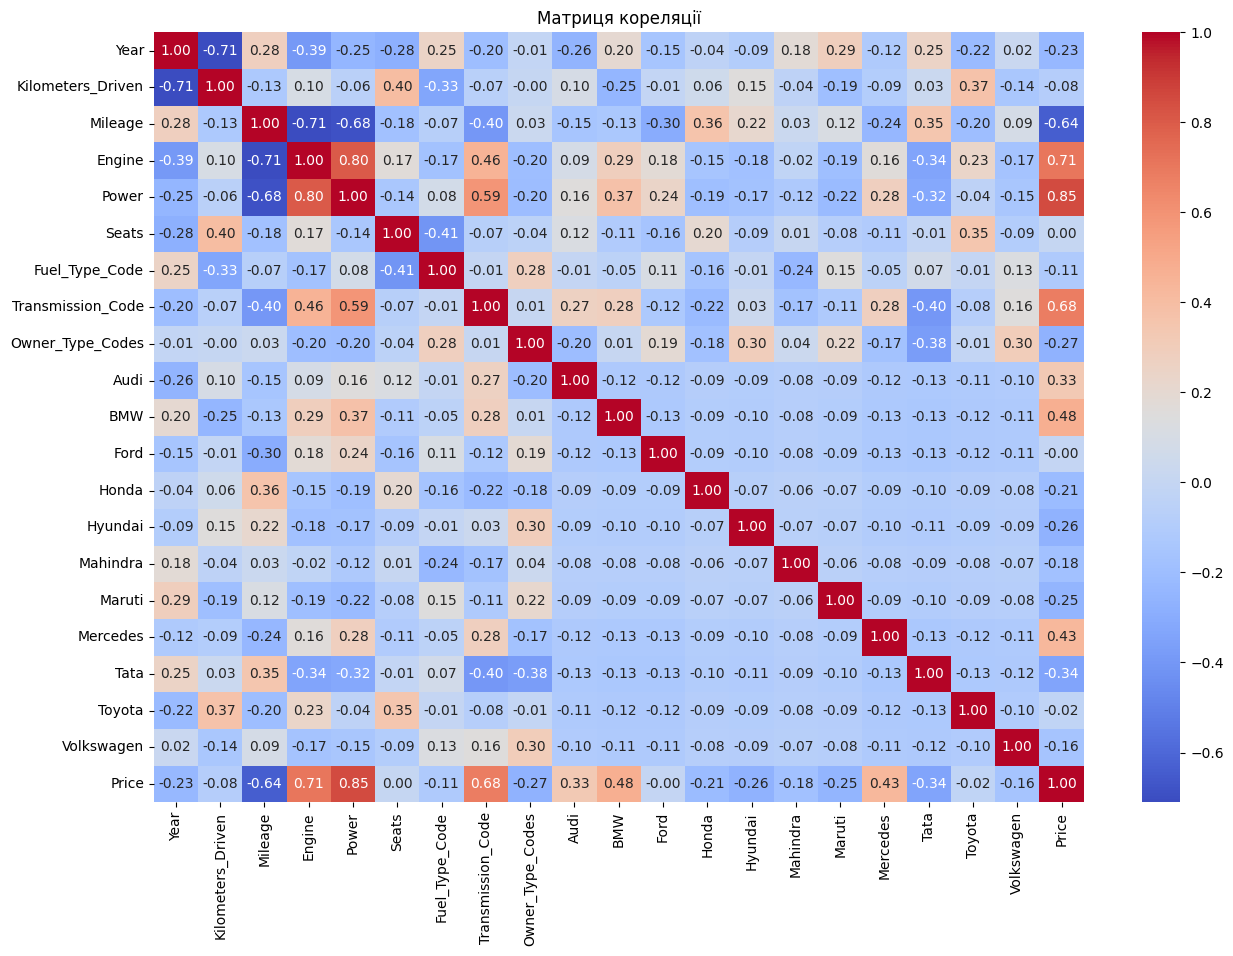


Кореляція з Price:
Price                1.000000
Power                0.849137
Engine               0.710561
Transmission_Code    0.680731
BMW                  0.477522
Mercedes             0.431606
Audi                 0.328858
Seats                0.000979
Ford                -0.004592
Toyota              -0.023778
Kilometers_Driven   -0.083951
Fuel_Type_Code      -0.110782
Volkswagen          -0.158742
Mahindra            -0.178627
Honda               -0.209779
Year                -0.233769
Maruti              -0.249737
Hyundai             -0.263022
Owner_Type_Codes    -0.265537
Tata                -0.341815
Mileage             -0.638404
Name: Price, dtype: float64


In [31]:
# Візуалізація
import seaborn as sns
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Матриця кореляції')
plt.show()

# Кореляція з Price
print("\nКореляція з Price:")
print(corr_matrix['Price'].sort_values(ascending=False))

**Висновок**
З цільовою змінною Price на рівні кореляції по модулю більше за 0.5 корелюють 4 ознаки:
Power (0.85), Engine (0.71), Transmission_Code (0.68);
Mileage (−0.64) має негативну кореляцію.

Тобто чим потужніший і об'ємніший двигун та чим частіше авто з автоматичною коробкою тим вища ціна; а вища Mileage (км/л) пов'язана з нижчою ціною, бо це переважно бюджетні машини з малим баком.

**Завдання 6**. Тренуємо лінійну регресію.
0. Видаліть усі НЕчислові колонки з `X_train`, `X_test`, якщо ще цього не зробили.
1. Натренуйте лінійну регресую з `sklearn` на усіх числових даних тренувального набору `X_train`.
2. Зробіть передбачення на  `X_train`, `X_test`. Знайдіть і виведіть root mean squared error відхилення передбачення від справжніх значень цільової змінної.
3. Побудуйте графік розсіювання передбачень проти реальних даних цільової змінної для тренувального і тестувального наборів даних. Що можете сказати про якість моделі?

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 0. Лишаємо тільки числові колонки
X_train = X_train.select_dtypes(include='number')
X_test = X_test.select_dtypes(include='number')

# 1. Тренуємо лінійну регресію на всіх числових даних
model = LinearRegression().fit(X_train, y_train)

# 2. Передбачення і RMSE на train і test
predictions_train = model.predict(X_train)
predictions_test = model.predict(X_test)

rmse_train = mean_squared_error(y_train, predictions_train) ** 0.5
rmse_test = mean_squared_error(y_test, predictions_test) ** 0.5

print('Train RMSE:', rmse_train)
print('Test RMSE:', rmse_test)

Train RMSE: 210342.80162046422
Test RMSE: 259601.26542723514


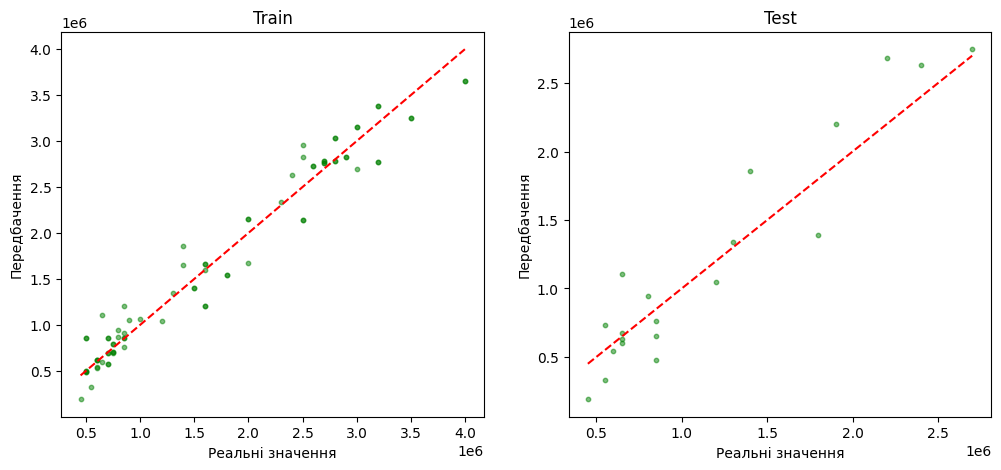

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_train, predictions_train, alpha=0.5, s=10, color='green')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')  # ідеальна лінія
plt.xlabel('Реальні значення')
plt.ylabel('Передбачення')
plt.title('Train')

plt.subplot(1, 2, 2)
plt.scatter(y_test, predictions_test, alpha=0.5, s=10, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Реальні значення')
plt.ylabel('Передбачення')
plt.title('Test')

plt.show()

**Висновки**
Train RMSE = 210342, Test RMSE = 259601. Помилка на тесті трохи більша, але модель нормально узагальнюється на нові дані.Що видно по червоній лінії. Даних в перевірці менше але тенденція зберігається.
Також розкид більший для дорогих авто, тобто в бюджетному сегменті модель точніша, а високі ціни передбачає гірше.

**Завдання 7**. Ми хочемо проаналізувати як впливає кожен чинник на цілову змінну. Для цього давайте промасштабуємо наші дані.
1. Зробіть масштабування незалежних змінних використовуючи `StandardScaler`. Тренуємо на тренувальних даних, а на тестувальних лише викликаємо `transform`.

2. Натренуйте модель на відмасштабованих даних і перегляньте коефіцієнти моделі. Які колонки є найвпливовішими на формування передбачення з точки зору коефіцієнтів? Проаналізуйте напрям дії найважливіших коефіцієнтів. Чи це логічно з точки зору значення відповідних змінних, що вони впливають на цільову змінну саме в напрямі збільшення / зменшення?

In [35]:
# 1. Масштабування
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Тренуємо модель на відмасштабованих даних
model_scaled = LinearRegression().fit(X_train_scaled, y_train)

# Збираємо коефіцієнти у таблицю і сортуємо за впливом
weights_df = pd.DataFrame({
    'feature': X_train.columns,
    'weight': model_scaled.coef_
})
weights_df['abs_weight'] = weights_df['weight'].abs()
weights_df.sort_values('abs_weight', ascending=False)

,feature,weight,abs_weight
4,Power,500000.506765,500000.506765
16,Mercedes,209257.737636,209257.737636
10,BMW,208105.079738,208105.079738
9,Audi,206123.092108,206123.092108
6,Fuel_Type_Code,-185245.840763,185245.840763
13,Hyundai,-151916.052473,151916.052473
14,Mahindra,-140931.632855,140931.632855
2,Mileage,-131884.633123,131884.633123
11,Ford,-119069.155830,119069.155830
7,Transmission_Code,115153.439599,115153.439599


Висновок. Найвпливовіша ознака — Power (+500K): потужність двигуна найсильніше підвищує ціну. Преміум-бренди (Mercedes, BMW, Audi) підвищують ціну, бюджетні (Hyundai, Mahindra, Maruti) навпаки знижують.
Mileage (−132K) відʼємний: економічніші авто дешевші.
Усі напрями логічні, окрім Engine тут кореляція відємна, хоча з ціною була позитивна.

**Завдання 8.** На тих самих відмасштабованих даних натренуйте модель з `statsmodels`. Виведіть звіт і проаналізуйте p-value коефіцієнтів. Які ознаки є стат значущими на рівні значущості 0.05? Напишіть їх список.

In [37]:
import statsmodels.api as sm

# Повертаємо назви колонок відмасштабованим даним (щоб у звіті були імена ознак)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)

# Додаємо константу (вільний член) і тренуємо OLS
X_sm = sm.add_constant(X_train_scaled_df)
ols_model = sm.OLS(y_train, X_sm)
results = ols_model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.959
Model:                            OLS   Adj. R-squared:                  0.946
Method:                 Least Squares   F-statistic:                     73.14
Date:                Sun, 28 Jun 2026   Prob (F-statistic):           2.34e-34
Time:                        18:02:31   Log-Likelihood:                -1094.0
No. Observations:                  80   AIC:                             2228.
Df Residuals:                      60   BIC:                             2276.
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               1.68e+06   2.72e+0

In [38]:
# Ознаки, значущі на рівні 0.05 (без константи)
significant = results.pvalues[results.pvalues < 0.05].drop('const', errors='ignore')
print('Значущі ознаки (p < 0.05):')
print(significant.sort_values())

Значущі ознаки (p < 0.05):
Power                3.439085e-09
Audi                 4.549697e-09
Mercedes             5.705474e-09
BMW                  1.263795e-08
Hyundai              1.789695e-06
Mahindra             1.149900e-05
Fuel_Type_Code       1.024429e-04
Maruti               2.230838e-04
Ford                 6.379237e-04
Volkswagen           2.563397e-03
Transmission_Code    8.990654e-03
Mileage              2.613313e-02
dtype: float64


## Висновок Завдання 8:

**Загальна якість моделі:**
- R**2 = 0.959 тобто модель пояснює 96% варіації ціни
- Adj. R**2 = 0.946 після корекції на кількість ознак теж високий
- F-statistic p-value = 2.34e-34 → модель в цілому значуща

**Статистично значущі ознаки (p < 0.05):**
- Power — найсильніший вплив, більша потужність = вища ціна
- Audi, BMW, Mercedes - преміум бренди значно дорожчі
- Hyundai, Mahindra, Maruti, Ford, Volkswagen - бюджетні бренди дешевші
- Fuel_Type_Code тип палива впливає на ціну
- Transmission_Code автоматична дорожча
- Mileage - вищий показник - нижча ціна

**Незначущі ознаки (p > 0.05):**
Year, Engine, Seats, Owner_Type_Codes, Honda, Tata, Toyota


**Завдання 9**. Натренуйте лінійну регресію з `statsmodels` тільки на ознаках, які виявлись стат. значущими в попередньому завданні. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared?

In [40]:
# Скидаємо індекси
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns).reset_index(drop=True)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_train.columns).reset_index(drop=True)
y_train_reset = y_train.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

# Навчання моделі тільки на значущих ознаках
X_train_sig = sm.add_constant(X_train_scaled_df[significant_features])
X_test_sig = sm.add_constant(X_test_scaled_df[significant_features])

model_sig = sm.OLS(y_train_reset, X_train_sig).fit()
print(model_sig.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.943
Method:                 Least Squares   F-statistic:                     109.4
Date:                Sun, 28 Jun 2026   Prob (F-statistic):           4.12e-39
Time:                        18:14:07   Log-Likelihood:                -1100.4
No. Observations:                  80   AIC:                             2227.
Df Residuals:                      67   BIC:                             2258.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               1.68e+06   2.78e+0

**Висновок**
- R**2 знизився лише з 0.959 до 0.951
- Adj. R**2 майже не змінився (0.946 → 0.943)
- Cond. No. впав з 7.47e+15 до 3.68 — мультиколінеарність повністю зникла
- Модель стала простішою (12 ознак замість 19) але майже не втратила точності

**Нові незначущі ознаки (p > 0.05):**
- Maruti (p=0.101), Ford (p=0.173), Volkswagen (p=0.487) стали незначущими після видалення інших ознак

Модель 9 краща і простіша.

**Завдання 10**. Натренуйте лінійну регресію з `statsmodels` на усіх ознаках з масштабованого `X_train`, у яких p_value в завданні 8 менше за `0.25`. Ми таким чином помʼякшили критерій відбору ознак. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared порівняно з завданням 8? Яку модель з останніх 3х завдань ви б лишили для використання?

In [41]:
# Ознаки з p_value < 0.25 з завдання 8
features_025 = ['Power', 'Audi', 'Mercedes', 'BMW', 'Hyundai',
                'Mahindra', 'Fuel_Type_Code', 'Maruti', 'Ford',
                'Volkswagen', 'Transmission_Code', 'Mileage',
                'Kilometers_Driven', 'Honda', 'Tata']  # p < 0.25

X_train_025 = sm.add_constant(X_train_scaled_df[features_025])

model_025 = sm.OLS(y_train_reset, X_train_025).fit()
print(model_025.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.958
Model:                            OLS   Adj. R-squared:                  0.948
Method:                 Least Squares   F-statistic:                     97.03
Date:                Sun, 28 Jun 2026   Prob (F-statistic):           4.85e-38
Time:                        18:17:35   Log-Likelihood:                -1094.7
No. Observations:                  80   AIC:                             2221.
Df Residuals:                      64   BIC:                             2260.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               1.68e+06   2.65e+0

**Висновки:**
- R**2 повернувся до 0.958 — майже як у моделі з усіма ознаками
- Adj. R**2 = 0.948 — найкращий з трьох моделей
- Cond. No. = 5.98 — мультиколінеарність відсутня
- Всі 15 ознак стали статистично значущими (p < 0.05)

**Яку модель обрати?**
Модель з Завдання 10 (p < 0.25) є найкращою: вища точність ніж в 9 (R**2=0.958 vs 0.951), без мультиколінеарності, всі ознаки значущі.